In [1]:
import pandas as pd
import numpy as np

/var/folders/fb/xl0hnskx527bfqkv38l3sn7h0000gn/T/ipykernel_12753/2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import seaborn as sns

In [3]:
data = {'ColB': {('A', 4): 3.0,
('C', 2): 0.0,
('B', 4): 51.0,
('B', 1): 0.0,
('C', 3): 0.0,
('B', 2): 7.0,
('A', 3): 5.0,
('C', 1): 0.0,
('C', 4): 0.0,
('B', 3): 12.0},
'ColA': {('A', 4): 66.0,
('C', 2): 5.0,
('B', 4): 125.0,
('B', 1): 5.0,
('C', 3): 41.0,
('B', 2): 52.0,
('A', 3): 22.0,
('C', 1): 14.0,
('C', 4): 51.0,
('B', 3): 122.0}}

df = pd.DataFrame(data)

In [4]:
import matplotlib.pyplot as plt

<Axes: >

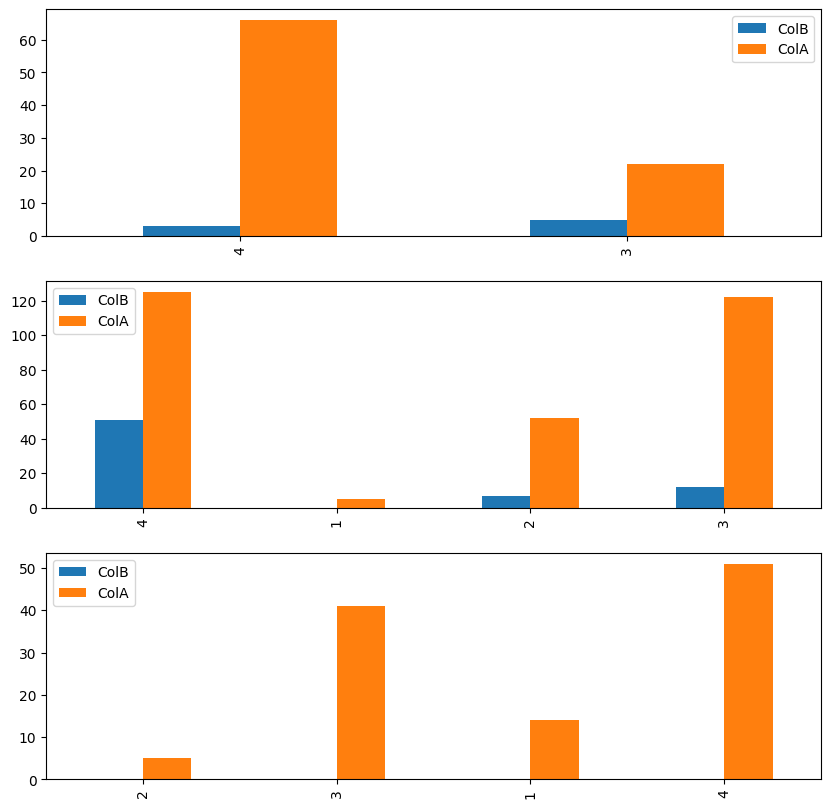

In [5]:
f,a=plt.subplots(3,1)
#dodelat velikost
df.xs('A').plot(kind='bar',ax=a[0],figsize=(10,10))
df.xs('B').plot(kind='bar',ax=a[1])
df.xs('C').plot(kind='bar',ax=a[2])

In [6]:
df.head()

ColB   ColA
A 4   3.0   66.0
C 2   0.0    5.0
B 4  51.0  125.0
  1   0.0    5.0
C 3   0.0   41.0

In [7]:
df.index.names=['code','names']
df

ColB   ColA
code names             
A    4       3.0   66.0
C    2       0.0    5.0
B    4      51.0  125.0
     1       0.0    5.0
C    3       0.0   41.0
B    2       7.0   52.0
A    3       5.0   22.0
C    1       0.0   14.0
     4       0.0   51.0
B    3      12.0  122.0

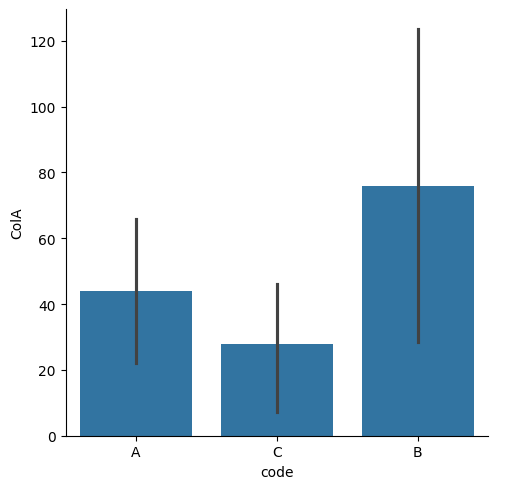

In [8]:
#reset_index doplni sloupce s nazvy sloupcu indexu
sns.catplot(x='code',y='ColA',data=df.reset_index(),kind='bar')

In [9]:
df.columns

Index(['ColB', 'ColA'], dtype='object')

In [10]:
df.reset_index().columns

Index(['code', 'names', 'ColB', 'ColA'], dtype='object')

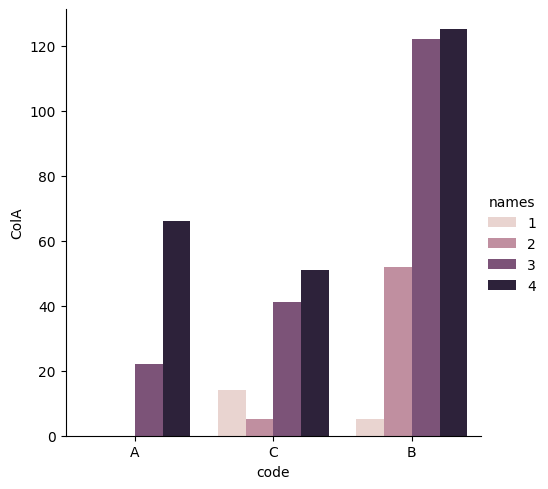

In [11]:
sns.catplot(x='code',y='ColA',data=df.reset_index(),kind='bar', hue='names')

In [12]:
group=('Group1','Group2')
sexes=('Male','Female')
means=('Low','High')
index = pd.MultiIndex.from_product([group, sexes,means],names=['Group','Sex','Mean'])

In [13]:
index

MultiIndex([('Group1',   'Male',  'Low'),
            ('Group1',   'Male', 'High'),
            ('Group1', 'Female',  'Low'),
            ('Group1', 'Female', 'High'),
            ('Group2',   'Male',  'Low'),
            ('Group2',   'Male', 'High'),
            ('Group2', 'Female',  'Low'),
            ('Group2', 'Female', 'High')],
           names=['Group', 'Sex', 'Mean'])

In [14]:
value=np.random.randint(low=20,high=100,size=len(index))

In [15]:
value

array([96, 97, 60, 86, 40, 99, 37, 52])

In [16]:
df=pd.DataFrame(data={'val':value}, index=index)
df

val
Group  Sex    Mean     
Group1 Male   Low    96
              High   97
       Female Low    60
              High   86
Group2 Male   Low    40
              High   99
       Female Low    37
              High   52

In [17]:
data=df.reset_index()

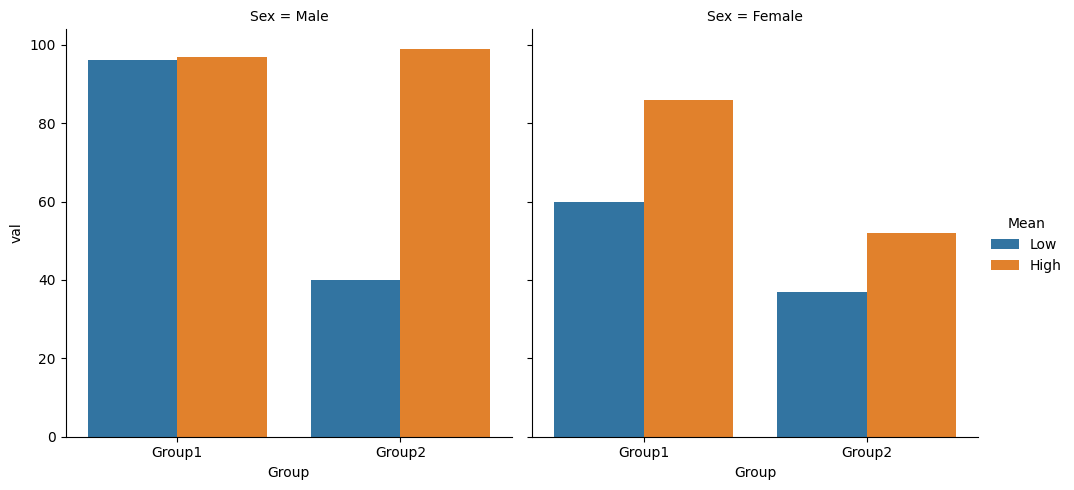

In [18]:
fg=sns.catplot(data=data, x='Group', y="val",kind='bar',col='Sex',hue='Mean')

In [19]:
data =sns.load_dataset('tips')

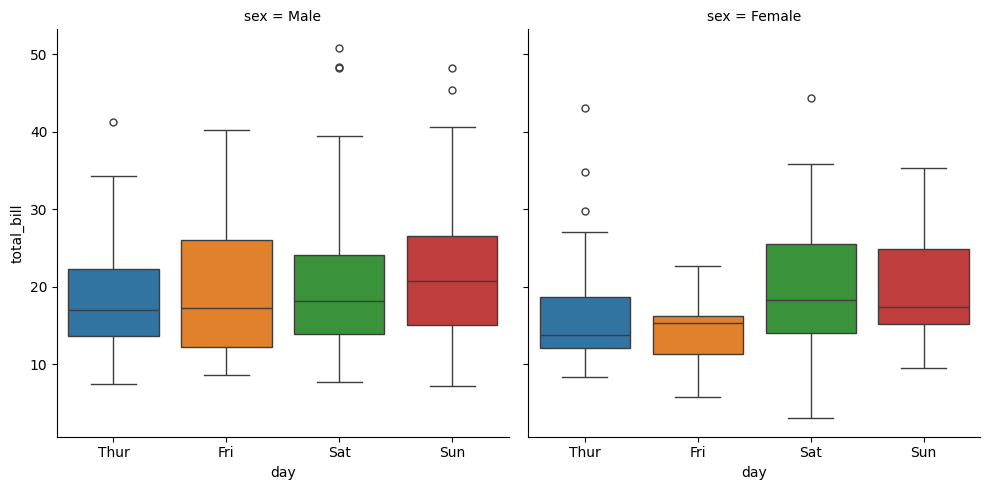

In [20]:
sns.catplot(x='day',y='total_bill',data=data,kind='box', col='sex', hue = 'day')

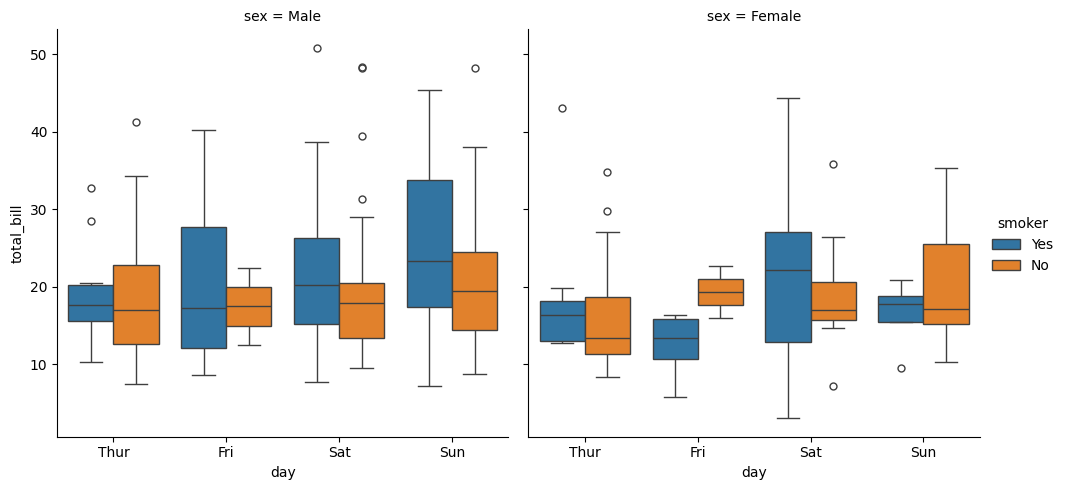

In [21]:
sns.catplot(x='day',y='total_bill',data=data,kind='box', col='sex', hue='smoker')

In [22]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000
